In [1]:
import os
import random
import sys
import matplotlib.pyplot as plt
import albumentations as A
import datetime
import numpy as np
import wandb
import time

from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torchinfo import summary
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset

from model.UNet import UNet
from model.RLUNet import RLUNet
from src.crack_segmentation.helper_func import set_dataset, dice_coeff, BCEDiceLoss, DiceLoss

c:\Users\ilham\Documents\Sipil\S2\THESIS\Coding\lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
! nvidia-smi

Sun Feb  8 23:08:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.17                 Driver Version: 561.17         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   57C    P8             10W /   80W |    1732MiB /  12282MiB |     17%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
print("CUDA Available:", torch.cuda.is_available())
print("DEVICE ID:", torch.cuda.current_device())
print("DEVICE NAME:", torch.cuda.get_device_name(0))

CUDA Available: True
DEVICE ID: 0
DEVICE NAME: NVIDIA GeForce RTX 4080 Laptop GPU


## TRAINING PARAMETERS

In [4]:
## TRAINING PARAMETERS
# epochs: int = 10
batch_size: int = 1
learning_rate: float = 1e-7
val_percent: float = 0.1
save_checkpoint: bool = True
img_scale: float = 0.5
amp: bool = False
weight_decay: float = 1e-8
momentum: float = 0.99
gradient_clipping: float = 1.0
img_dim = (400, 400)


## SETUP & OPTIMIZER

In [6]:
## SETUP OPTIMIZER
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = RLUNet().to(device)
model = UNet(n_channels=3, n_classes=1).to(device)

# Using Adam optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
    foreach=True
)

# Data Loader
database_name = "CC"
train_dataset, test_dataset, validation_dataset = set_dataset(dataset=database_name, img_dim=None)

train_dataloader = DataLoader(dataset=train_dataset, 
                              pin_memory=True,
                              batch_size=batch_size,
                              shuffle=True)

val_dataloader = DataLoader(dataset=validation_dataset, 
                            pin_memory=True,
                            batch_size=batch_size,
                            shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset, 
                             pin_memory=True,
                             batch_size=batch_size,
                             shuffle=True)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)
grad_scaler = torch.cuda.amp.GradScaler('cuda', enabled=amp)
criterion = nn.BCEWithLogitsLoss()
# criterion = nn.CrossEntropyLoss()
# criterion = BCEDiceLoss()
# criterion = DiceLoss()
# criterion = nn.MSELoss(reduction='mean')
global_step = 0

C:\Users\ilham\AppData\Local\Temp\ipykernel_22404\1660736066.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  grad_scaler = torch.cuda.amp.GradScaler('cuda', enabled=amp)


## TRAINING LOOP

In [7]:
torch.cuda.empty_cache()

In [8]:
EPOCHS = 200

# model save path

model_save_path = '/model_state/'

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

# CONTINUE TRAINING
# model_dir_final = "./model_state/FINAL_RLUNET_OmniCrack30k_100_16.pth"
# ckpt = torch.load(model_dir_final)
# model.load_state_dict(ckpt['state_dict'], strict=False)
# optimizer.load_state_dict(ckpt['optimizer'])
# start_epoch = ckpt['epoch']

since = time.time()

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0

    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):

        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)

        y_pred = model(img)
        optimizer.zero_grad()

        dc = dice_coeff(y_pred, mask)
        loss = criterion(y_pred, mask)

        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)

    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0

    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = dice_coeff(y_pred, mask)

            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)

    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 40)
    print(f"EPOCH {epoch + 1}")
    print(f"Train Loss: {train_loss:.4f}", end=" ")
    print(f"Train DICE: {train_dc:.4f}", end=" ")
    print(f"Val Loss: {val_loss:.4f}", end=" ")
    print(f"Val DICE: {val_dc:.4f}")
    print("-" * 40)

    checkpoint = {
        'epoch': epoch + 1,
        'state_dict': model.state_dict(),
        'optimizer': optimizer.state_dict()
    }

    # torch.save(checkpoint, f"model_state/UNet/{database_name}_{epoch+1}_{batch_size}.pth")

# MODEL CHECKPOINT (MODEL SAVE)
checkpoint_datetime = datetime.datetime.now()
day = checkpoint_datetime.strftime("%d")
month = checkpoint_datetime.strftime("%m")
year = checkpoint_datetime.strftime("%y")
hour = checkpoint_datetime.strftime("%H")
minute = checkpoint_datetime.strftime("%M")
second = checkpoint_datetime.strftime("%S")

end = time.time()
print(f"Finish in: {round(end-since / 60, 2)} s")

## FINAL MODEL
torch.save(checkpoint, f"model_state/FINAL_UNET_{database_name}_{EPOCHS}_{batch_size}_FULLRES.pth")

  0%|          | 0/200 [00:22<?, ?it/s]


KeyboardInterrupt: 

In [14]:
## SAVE FINAL CHECKPOINT IF TRAINING CANCEL IN THE MIDDLE
torch.save(checkpoint, f"model_state/FINAL_UNET_{database_name}_{EPOCHS}_{batch_size}_FULLRES.pth")

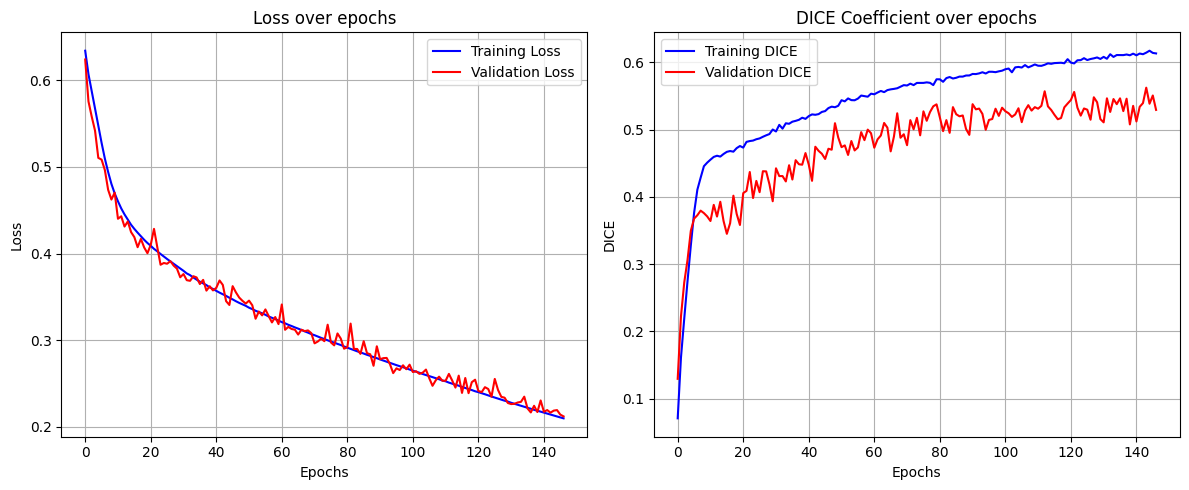

In [16]:
epochs_list = list(range(0, epoch))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, color='b', label='Training Loss')
plt.plot(epochs_list, val_losses, color='r', label='Validation Loss')
# plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_dcs, color='b', label='Training DICE')
plt.plot(epochs_list, val_dcs, color='r', label='Validation DICE')
# plt.xticks(ticks=list(range(1, EPOCHS + 1, 1)))  
plt.title('DICE Coefficient over epochs')
plt.xlabel('Epochs')
plt.ylabel('DICE')
plt.grid()
plt.legend()

plt.tight_layout()
plt.savefig(f"Graph Performance/UNet_{database_name}_BATCHSIZE{batch_size}_E{epoch}_{400}.png", dpi=1200)
plt.show()